# Online misogyny dataset audit

This notebook inspects the Online Misogyny EACL 2021 dataset stored under `datasets/online-misogyny-eacl2021-main`. It answers the requested audit questions and keeps row-level and unique-post counts separate, because `final_labels.csv` contains repeated `entry_id` values when a post has multiple final labels.

In [1]:
from pathlib import Path
import ast
import hashlib
import importlib.util
import re
import shutil
import subprocess
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)

def find_dataset_root(start=Path.cwd()):
    """Find the dataset whether the notebook runs from the repo root or notebooks/."""
    for directory in [start, *start.parents]:
        candidate = directory / "datasets" / "online-misogyny-eacl2021-main"
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find datasets/online-misogyny-eacl2021-main from " + str(start))


DATASET_ROOT = find_dataset_root()
DATA_DIR = DATASET_ROOT / "data"
FINAL_CSV = DATA_DIR / "final_labels.csv"
ORIGINAL_CSV = DATA_DIR / "original_labels.csv"
IMAGE_DIR = DATA_DIR / "dataset_post_images"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".gif", ".bmp", ".webp", ".tif", ".tiff"}

for path in [FINAL_CSV, ORIGINAL_CSV, IMAGE_DIR]:
    if not path.exists():
        raise FileNotFoundError(path)

print("Dataset root:", DATASET_ROOT)
print("Final labels:", FINAL_CSV)
print("Image directory:", IMAGE_DIR)

Dataset root: /Users/axelturin-plessia/Documents/EPFL/Master/MA2/Deep Learning/EE559-DeepLearningProject-g37/datasets/online-misogyny-eacl2021-main
Final labels: /Users/axelturin-plessia/Documents/EPFL/Master/MA2/Deep Learning/EE559-DeepLearningProject-g37/datasets/online-misogyny-eacl2021-main/data/final_labels.csv
Image directory: /Users/axelturin-plessia/Documents/EPFL/Master/MA2/Deep Learning/EE559-DeepLearningProject-g37/datasets/online-misogyny-eacl2021-main/data/dataset_post_images


## Load Labels

`keep_default_na=False` keeps empty CSV cells as empty strings. That makes it easier to distinguish missing text from pandas `NaN` values and to inspect unexpected values in the `image` column.

In [2]:
final = pd.read_csv(FINAL_CSV, keep_default_na=False)
original = pd.read_csv(ORIGINAL_CSV, keep_default_na=False)

print(f"final_labels.csv: {len(final):,} rows, {final['entry_id'].nunique():,} unique entry_id values")
print(f"original_labels.csv: {len(original):,} rows, {original['entry_id'].nunique():,} unique entry_id values")
display(final.head(3))

final_labels.csv: 6,567 rows, 6,383 unique entry_id values
original_labels.csv: 15,816 rows, 6,383 unique entry_id values


,entry_id,link_id,parent_id,entry_utc,subreddit,author,body,image,label_date,week,group,sheet_order,level_1,level_2,level_3,strength,highlight,split
0,exoxn7,t3_exoxn7,,1580652620,badwomensanatomy,doggodone,"Do you have the skin of a 80 year old grandma? Worry no more, just drink water!",Yes,17-02-2020,1,1,"(1,)",Nonmisogynistic,None_of_the_categories,,,,train
1,fgb3bdv,t3_exoxn7,t3_exoxn7,1580658139,badwomensanatomy,Machaeon,"This is taking a grain of truth and extrapolating to insanity.\n\nStay hydrated, it's healthy, you'll look and feel better. It will not reverse the aging process though.",,17-02-2020,1,1,"(1, 1)",Nonmisogynistic,None_of_the_categories,,,,train
2,fgc6tlu,t3_exoxn7,t3_exoxn7,1580669695,badwomensanatomy,CuniculusVincitOmnia,Honestly my favorite thing about this is that they feel the need to cite beauty professionals in order to prove that dehydration is caused by not drinking enough water.,,17-02-2020,1,1,"(1, 2)",Nonmisogynistic,None_of_the_categories,,,,test


## Normalize Audit Fields

Some rows contain text fragments in the `image` column instead of the expected blank/`Yes` marker. Those appear to be source CSV quoting issues where an unquoted comma split the post body. The audit keeps the raw column, flags those rows, and uses a repaired `text_for_audit` field for text checks.

In [3]:
def parse_top_sheet_order(value):
    """Return the first integer from sheet_order strings such as '(12, 2, 1)'."""
    try:
        parsed = ast.literal_eval(str(value))
    except (SyntaxError, ValueError):
        return pd.NA
    if isinstance(parsed, tuple) and parsed:
        try:
            return int(parsed[0])
        except (TypeError, ValueError):
            return pd.NA
    return pd.NA


def join_body_fragment(row):
    body = str(row["body_raw"])
    fragment = str(row["image_raw"]).strip()
    if not fragment:
        return body
    return f"{body}, {fragment}" if body.strip() else fragment


df = final.copy()
df["body_raw"] = df["body"].astype(str)
df["image_raw"] = df["image"].astype(str)
df["image_value"] = df["image_raw"].str.strip()
df["image_flag"] = df["image_value"].str.casefold().eq("yes")
df["malformed_image_value"] = (~df["image_flag"]) & df["image_value"].ne("")

df["text_for_audit"] = df["body_raw"]
df.loc[df["malformed_image_value"], "text_for_audit"] = df.loc[df["malformed_image_value"]].apply(join_body_fragment, axis=1)
df["text_empty"] = df["text_for_audit"].str.strip().eq("")

df["sheet_top_order"] = df["sheet_order"].map(parse_top_sheet_order).astype("Int64")
df["expected_image_file"] = ""
image_rows = df["image_flag"] & df["sheet_top_order"].notna()
df.loc[image_rows, "expected_image_file"] = (
    df.loc[image_rows, "week"].astype(str)
    + "_"
    + df.loc[image_rows, "group"].astype(str)
    + "_"
    + df.loc[image_rows, "sheet_top_order"].astype(str)
    + ".jpg"
)
df["expected_image_path"] = df["expected_image_file"].map(lambda name: IMAGE_DIR / name if name else pd.NA)
df["expected_image_exists"] = df["expected_image_file"].map(lambda name: (IMAGE_DIR / name).exists() if name else False)

print("Unexpected non-empty/non-Yes image values:", int(df["malformed_image_value"].sum()))
if df["malformed_image_value"].any():
    display(df.loc[df["malformed_image_value"], ["entry_id", "body", "image", "text_for_audit", "week", "group", "sheet_order"]])

Unexpected non-empty/non-Yes image values: 14


,entry_id,body,image,text_for_audit,week,group,sheet_order
178,fghhw19,You know the red pill is a myth right? The only true pill is the honk pill,everything else is fantasy,"You know the red pill is a myth right? The only true pill is the honk pill, everything else is fantasy",1,2,"(12, 2, 1, 1)"
373,fgw031t,go treat yourself! :) now's a great time to buy jewellery cos of all the promotions anyway,),"go treat yourself! :) now's a great time to buy jewellery cos of all the promotions anyway, )",2,1,"(8, 3, 1, 1, 1, 1)"
673,fid38a2,I don't understand why you'd want to harm your own wife. That's *your* wife,that's like keying your own car.,"I don't understand why you'd want to harm your own wife. That's *your* wife, that's like keying your own car.",3,1,"(1, 10)"
752,fijv8md,I call it BS sindrome,),"I call it BS sindrome, )",3,1,"(7, 4)"
808,fhybtzk,Could be worse,NBC could've sent out Tara and Johnny to cover the game.,"Could be worse, NBC could've sent out Tara and Johnny to cover the game.",3,1,"(11, 3)"
953,fihlafo,Acceptance and being at peace with it,that can be very hard to attain but you are clearly in a very good space and that is a good thing.,"Acceptance and being at peace with it, that can be very hard to attain but you are clearly in a very good space and that is a good thing.",3,2,"(22, 2)"
1321,fizxu7g,I would also love if we get a new jutsu using the jougan,It is tiring to see rasengan and its variations all the time. Kenjutsu it's also cool for Boruto to have and maybe he could make chakra weapons like Momoshiki.,"I would also love if we get a new jutsu using the jougan, It is tiring to see rasengan and its variations all the time. Kenjutsu it's also cool for Boruto to have and maybe he ...",4,1,"(13, 1, 2, 1, 1, 1)"
1613,fj5fi7c,I wish they would fund more Feminist movies,either they'll realize that if they get woke they go broke so they change or Hollywood does go broke and new industries can arise.,"I wish they would fund more Feminist movies, either they'll realize that if they get woke they go broke so they change or Hollywood does go broke and new industries can arise.",4,2,"(36, 2, 1)"
1618,fj5mux2,That's not woman,that's a man. XD,"That's not woman, that's a man. XD",4,2,"(36, 4, 2)"
1867,fek8hm,Anyone here like Dakota R/T's? Pretty sure mine is the cleanest,),"Anyone here like Dakota R/T's? Pretty sure mine is the cleanest, )",5,1,"(20,)"


## Core Dataset Counts

In [4]:
row_label_counts = df["level_1"].value_counts().rename_axis("level_1").reset_index(name="row_count")

def collapse_label(labels):
    values = tuple(sorted(set(labels)))
    if values == ("Misogynistic",):
        return "Misogynistic"
    if values == ("Nonmisogynistic",):
        return "Nonmisogynistic"
    return "Conflict: " + " + ".join(values)

post_summary = (
    df.groupby("entry_id", as_index=True)
    .agg(
        row_count=("entry_id", "size"),
        level_1_collapsed=("level_1", collapse_label),
        has_image=("image_flag", "any"),
        has_empty_text=("text_empty", "any"),
        has_malformed_image_value=("malformed_image_value", "any"),
    )
)
post_label_counts = post_summary["level_1_collapsed"].value_counts().rename_axis("level_1_collapsed").reset_index(name="unique_post_count")

core_counts = pd.DataFrame(
    [
        ("final label rows", len(df)),
        ("unique posts by entry_id", df["entry_id"].nunique()),
        ("misogynistic rows", int((df["level_1"] == "Misogynistic").sum())),
        ("non-misogynistic rows", int((df["level_1"] == "Nonmisogynistic").sum())),
        ("unique misogynistic posts", int((post_summary["level_1_collapsed"] == "Misogynistic").sum())),
        ("unique non-misogynistic posts", int((post_summary["level_1_collapsed"] == "Nonmisogynistic").sum())),
        ("unique posts with conflicting level_1 labels", int(post_summary["level_1_collapsed"].str.startswith("Conflict:").sum())),
        ("image-flagged rows", int(df["image_flag"].sum())),
        ("unique image-flagged posts", int(post_summary["has_image"].sum())),
    ],
    columns=["metric", "value"],
)

display(core_counts)
display(row_label_counts)
display(post_label_counts)

,metric,value
0,final label rows,6567
1,unique posts by entry_id,6383
2,misogynistic rows,699
3,non-misogynistic rows,5868
4,unique misogynistic posts,515
5,unique non-misogynistic posts,5867
6,unique posts with conflicting level_1 labels,1
7,image-flagged rows,173
8,unique image-flagged posts,172


,level_1,row_count
0,Nonmisogynistic,5868
1,Misogynistic,699


,level_1_collapsed,unique_post_count
0,Nonmisogynistic,5867
1,Misogynistic,515
2,Conflict: Misogynistic + Nonmisogynistic,1


## Unicode Emoji Check

This counts Unicode emoji code points in the raw/repaired post text. ASCII emoticons such as `:)` are not counted as Unicode emoji.

In [5]:
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F1E6-\U0001F1FF"
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\u2600-\u27BF"
    "]"
)

df["has_unicode_emoji"] = df["text_for_audit"].map(lambda text: bool(EMOJI_PATTERN.search(text)))
emoji_rows = int(df["has_unicode_emoji"].sum())
emoji_posts = int(df.loc[df["has_unicode_emoji"], "entry_id"].nunique())

print(f"Rows containing Unicode emoji: {emoji_rows:,}")
print(f"Unique posts containing Unicode emoji: {emoji_posts:,}")

if emoji_rows:
    display(df.loc[df["has_unicode_emoji"], ["entry_id", "text_for_audit", "level_1"]].head(20))

Rows containing Unicode emoji: 0
Unique posts containing Unicode emoji: 0


## Image File Checks

Image filenames appear to follow `{week}_{group}_{top_level_sheet_order}.jpg` for rows where `image == Yes`. The audit uses that convention to check for missing or extra files, while also reporting the raw number of image files found on disk.

In [6]:
image_files = sorted([p for p in IMAGE_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
non_image_files = sorted([p for p in IMAGE_DIR.iterdir() if p.is_file() and p.suffix.lower() not in IMAGE_EXTENSIONS])
actual_image_names = {p.name for p in image_files}
expected_image_names = set(df.loc[df["image_flag"], "expected_image_file"]) - {""}
missing_expected_images = sorted(expected_image_names - actual_image_names)
extra_image_files = sorted(actual_image_names - expected_image_names)

image_inspection = []
for path in image_files:
    row = {"file": path.name, "path": str(path), "readable": True, "width": pd.NA, "height": pd.NA, "error": ""}
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            row["width"], row["height"] = img.size
    except Exception as exc:
        row["readable"] = False
        row["error"] = repr(exc)
    image_inspection.append(row)

image_inspection_df = pd.DataFrame(image_inspection)
broken_images = image_inspection_df.loc[~image_inspection_df["readable"]] if len(image_inspection_df) else pd.DataFrame()

hash_groups = defaultdict(list)
for path in image_files:
    if path.exists() and path.is_file():
        hash_groups[hashlib.md5(path.read_bytes()).hexdigest()].append(path.name)
duplicate_image_groups = [sorted(names) for names in hash_groups.values() if len(names) > 1]

image_quality_summary = pd.DataFrame(
    [
        ("image-flagged rows", int(df["image_flag"].sum())),
        ("unique image-flagged posts", int(df.loc[df["image_flag"], "entry_id"].nunique())),
        ("unique expected image filenames", len(expected_image_names)),
        ("image files found on disk", len(image_files)),
        ("non-image files in image directory", len(non_image_files)),
        ("missing expected image files", len(missing_expected_images)),
        ("extra image files not mapped from labels", len(extra_image_files)),
        ("broken/unreadable image files", int((~image_inspection_df["readable"]).sum()) if len(image_inspection_df) else 0),
        ("duplicate image-content groups", len(duplicate_image_groups)),
        ("extra duplicate image files by content", sum(len(group) - 1 for group in duplicate_image_groups)),
    ],
    columns=["metric", "value"],
)

display(image_quality_summary)

print("Missing expected image files:")
display(pd.DataFrame({"missing_expected_image_file": missing_expected_images}))

print("Extra image files not mapped from labels:")
display(pd.DataFrame({"extra_image_file": extra_image_files}))

print("Non-image files in image directory:")
display(pd.DataFrame({"non_image_file": [p.name for p in non_image_files]}))

print("Duplicate image content groups:")
display(pd.DataFrame({"duplicate_group": duplicate_image_groups}))

if len(broken_images):
    display(broken_images)

,metric,value
0,image-flagged rows,173
1,unique image-flagged posts,172
2,unique expected image filenames,172
3,image files found on disk,169
4,non-image files in image directory,1
5,missing expected image files,29
6,extra image files not mapped from labels,26
7,broken/unreadable image files,0
8,duplicate image-content groups,2
9,extra duplicate image files by content,2


Missing expected image files:


,missing_expected_image_file
0,10_2_49.jpg
1,10_2_57.jpg
2,10_2_63.jpg
3,10_2_64.jpg
4,10_2_69.jpg
5,10_2_72.jpg
6,10_2_75.jpg
7,10_2_78.jpg
8,10_2_84.jpg
9,1_1_1.jpg


Extra image files not mapped from labels:


,extra_image_file
0,10_2_50.jpg
1,10_2_59.jpg
2,10_2_65.jpg
3,10_2_66.jpg
4,10_2_73.jpg
5,10_2_74.jpg
6,10_2_77.jpg
7,10_2_82.jpg
8,10_2_88.jpg
9,11_2_78.jpg


Non-image files in image directory:


,non_image_file
0,.DS_Store


Duplicate image content groups:


,duplicate_group
0,"[8_1_7.jpg, 9_2_55.jpg]"
1,"[9_1_2.jpg, 9_2_58.jpg]"


## Optional OCR: Readable Text Inside Images

This cell tries to run OCR through either `pytesseract` or a `tesseract` command-line binary. If neither is installed, it leaves the image-text count as not computed instead of failing the notebook. To enable it locally, install the Tesseract system binary and the Python `pytesseract` package, then rerun this cell.

In [7]:
import shutil
import pytesseract

print(shutil.which("tesseract"))
print(pytesseract.get_tesseract_version())


/opt/homebrew/bin/tesseract
5.5.2


In [8]:
def get_ocr_backend():
    if importlib.util.find_spec("pytesseract") is not None:
        try:
            import pytesseract

            pytesseract.get_tesseract_version()
            return "pytesseract", pytesseract
        except Exception as exc:
            print("pytesseract is installed but not usable:", repr(exc))

    tesseract_cli = shutil.which("tesseract")
    if tesseract_cli:
        return "tesseract_cli", tesseract_cli

    return None, None


def ocr_image(path, backend_name, backend):
    if backend_name == "pytesseract":
        with Image.open(path) as img:
            return backend.image_to_string(img)
    if backend_name == "tesseract_cli":
        completed = subprocess.run(
            [backend, str(path), "stdout", "--psm", "6", "-l", "eng"],
            check=False,
            capture_output=True,
            text=True,
            timeout=30,
        )
        return completed.stdout
    return ""


MIN_READABLE_CHARS = 3
ocr_backend_name, ocr_backend = get_ocr_backend()
ocr_status = "not computed: no pytesseract package or tesseract CLI available"
readable_image_file_count = None
readable_image_post_count = None
ocr_results = pd.DataFrame(columns=["file", "ocr_text", "ocr_text_clean", "has_readable_text", "error"])

if ocr_backend_name is None:
    print(ocr_status)
else:
    rows = []
    for path in image_files:
        error = ""
        try:
            text = ocr_image(path, ocr_backend_name, ocr_backend)
        except Exception as exc:
            text = ""
            error = repr(exc)
        cleaned = re.sub(r"\s+", " ", text).strip()
        has_readable_text = bool(re.search(r"[A-Za-z0-9]", cleaned)) and len(cleaned) >= MIN_READABLE_CHARS
        rows.append(
            {
                "file": path.name,
                "ocr_text": text,
                "ocr_text_clean": cleaned,
                "has_readable_text": has_readable_text,
                "error": error,
            }
        )

    ocr_results = pd.DataFrame(rows)
    readable_files = set(ocr_results.loc[ocr_results["has_readable_text"], "file"])
    readable_image_file_count = len(readable_files)
    readable_image_post_count = df.loc[df["expected_image_file"].isin(readable_files), "entry_id"].nunique()
    ocr_status = f"computed with {ocr_backend_name}"

    print("OCR status:", ocr_status)
    print(f"Image files with readable OCR text: {readable_image_file_count:,}")
    print(f"Mapped unique image posts with readable OCR text: {readable_image_post_count:,}")
    display(ocr_results.loc[ocr_results["has_readable_text"], ["file", "ocr_text_clean"]].head(30))

OCR status: computed with pytesseract
Image files with readable OCR text: 131
Mapped unique image posts with readable OCR text: 112


,file,ocr_text_clean
0,10_1_1.jpg,fe ) ‘Onyekachi Can sex doll cook your meals? Can sex doll have your kids? Can sex doll wash your clothe Can sex doll make your home? What's it? You'll are really triggered TBH...
1,10_1_12.jpg,Bois Locker Room: Girl created fake account to setts sex assault plan ‘NewDelhi:Itwasagitiwhohad 0 = 5 DCP (cyber ool) Anyesh Roy sr rinsexual _saic:“Thereweremany screens stop...
5,10_1_32.jpg,being ugly is so disheartening you be having a good time and then get a glimpse of ya reflection and it kill ur whole mood
6,10_1_33.jpg,"A Video From 3 Years Ago Resurfaced Of Cardi B Admitting To Drugging And Robbing Men After Thinking They Were Going To Have Sex. Women Are Going Hard For Her S: ying ""It was ye..."
7,10_1_35.jpg,"09/26/19(Thu)21:58:59 No.121597357 >Goes to prostitute >""Alright honey what do ya want? $50 to blow $100 for the night. $250 for anal, but ya gotta wear a 40 KB JPG Tubbah’ >l-..."
8,10_1_36.jpg,Queens Leveling xX ‘€ x °\ XN yi PA.
9,10_1_37.jpg,| told my sister to write an essay on the wage gap for her class & this is her professor's reply ne reason why you are having this problem is 6d to look at feminist sources on ...
10,10_1_40.jpg,", 9 BEING A VIRGIN} Sao [TM SURE ITLL} CTA Must be ItaTERL GOMER él"
12,10_1_43.jpg,This is just horrible 7 — 12 year old boy appears in court on felony charge..for selling CDs at a mall - Black Scene Daycare provider who hanged toddler in her basement sentenc...
13,10_1_44.jpg,"fishin: redbywartosoatosnosae Bo El 92 Ysk Ifyou think women should dll the cooking and leaning, you're not looking for a wife you're looking for someone to replace your mother..."


## Compare Tesseract and EasyOCR on One Image

This compares both OCR engines on the same image: the first image where the Tesseract OCR pass found readable text. If EasyOCR is not installed, the cell reports how to enable the comparison instead of failing.

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Comparison image: 10_1_1.jpg


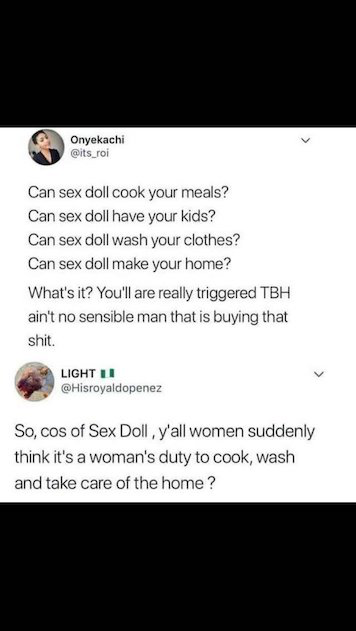

,engine,status,text,char_count,word_count
0,Tesseract,computed with pytesseract,fe ) ‘Onyekachi Can sex doll cook your meals? Can sex doll have your kids? Can sex doll wash your clothe Can sex doll make your home? What's it? You'll are really triggered TBH...,344,70
1,EasyOCR,computed with easyocr,Onyekachi @its_roi Can sex doll cook your meals? Can sex dollhave your kids? Can sex doll wash your clothes? Can sex doll make your home? What'sit? You'Il are really triggered ...,357,64


In [9]:
def normalize_ocr_text(text):
    return re.sub(r"\s+", " ", str(text)).strip()


def run_tesseract_for_comparison(path):
    backend_name, backend = get_ocr_backend()
    if backend_name is None:
        return "", "not available: no pytesseract package or tesseract CLI available"
    try:
        return normalize_ocr_text(ocr_image(path, backend_name, backend)), f"computed with {backend_name}"
    except Exception as exc:
        return "", "error: " + repr(exc)


def run_easyocr_for_comparison(path):
    if importlib.util.find_spec("easyocr") is None:
        return "", "not installed: run `pip install easyocr` or `conda install -c conda-forge easyocr`"
    try:
        import easyocr

        reader = easyocr.Reader(["en"], gpu=False, verbose=False)
        pieces = reader.readtext(str(path), detail=0, paragraph=True)
        return normalize_ocr_text(" ".join(pieces)), "computed with easyocr"
    except Exception as exc:
        return "", "error: " + repr(exc)


if len(image_files) == 0:
    print("No image files available for OCR comparison.")
    ocr_comparison = pd.DataFrame(columns=["engine", "status", "text", "char_count", "word_count"])
else:
    if "ocr_results" in globals() and len(ocr_results) and ocr_results["has_readable_text"].any():
        first_ocr_file = ocr_results.loc[ocr_results["has_readable_text"], "file"].iloc[0]
        comparison_image_path = IMAGE_DIR / first_ocr_file
    else:
        comparison_image_path = image_files[0]

    tesseract_text, tesseract_status = run_tesseract_for_comparison(comparison_image_path)
    easyocr_text, easyocr_status = run_easyocr_for_comparison(comparison_image_path)

    ocr_comparison = pd.DataFrame(
        [
            {
                "engine": "Tesseract",
                "status": tesseract_status,
                "text": tesseract_text,
                "char_count": len(tesseract_text),
                "word_count": len(tesseract_text.split()),
            },
            {
                "engine": "EasyOCR",
                "status": easyocr_status,
                "text": easyocr_text,
                "char_count": len(easyocr_text),
                "word_count": len(easyocr_text.split()),
            },
        ]
    )

    print("Comparison image:", comparison_image_path.name)
    display(Image.open(comparison_image_path))
    display(ocr_comparison)


## OCR Emoji and Emoji-Like Token Detection

OCR is not a reliable way to detect graphical emoji in images. It can, however, report emoji if the engine outputs Unicode emoji characters, and it can detect emoji-like text tokens such as `:)`, `:-D`, `XD`, `<3`, or textual aliases like `:smile:`. For robust detection of graphical emoji inside images, use image-based detection or template matching instead of OCR alone.

In [10]:
OCR_EMOTICON_PATTERN = re.compile(
    r"""(?ix)
    (?<![A-Za-z0-9_])
    (
        <3
        | [xX]-?[dDpP]
        | [:;=8]["'`\-oO]?[)D(Pp/\\|sS3]
        | \^[._-]?\^
        | :[a-z][a-z0-9_+\-]*:
    )
    (?![A-Za-z0-9_])
    """
)
OCR_LAUGHTER_PATTERN = re.compile(r"(?i)\b(?:lol|lmao|rofl)\b")


def find_ocr_emoji_tokens(text):
    text = str(text)
    unicode_tokens = [match.group(0) for match in EMOJI_PATTERN.finditer(text)]
    emoji_like_tokens = [match.group(0) for match in OCR_EMOTICON_PATTERN.finditer(text)]
    laughter_tokens = [match.group(0) for match in OCR_LAUGHTER_PATTERN.finditer(text)]
    return unicode_tokens, emoji_like_tokens, laughter_tokens


def build_ocr_emoji_report(source_name, results_df):
    if results_df is None or len(results_df) == 0:
        return pd.DataFrame(columns=["source", "file", "unicode_emoji", "emoji_like_tokens", "laughter_tokens", "ocr_text_clean"])

    text_col = "ocr_text_clean" if "ocr_text_clean" in results_df.columns else "text"
    rows = []
    for _, row in results_df.iterrows():
        unicode_tokens, emoji_like_tokens, laughter_tokens = find_ocr_emoji_tokens(row.get(text_col, ""))
        if unicode_tokens or emoji_like_tokens or laughter_tokens:
            rows.append(
                {
                    "source": source_name,
                    "file": row.get("file", comparison_image_path.name if "comparison_image_path" in globals() else ""),
                    "unicode_emoji": unicode_tokens,
                    "emoji_like_tokens": emoji_like_tokens,
                    "laughter_tokens": laughter_tokens,
                    "ocr_text_clean": row.get(text_col, ""),
                }
            )
    return pd.DataFrame(rows)


reports = []
if "ocr_results" in globals() and len(ocr_results):
    reports.append(build_ocr_emoji_report("Tesseract full image scan", ocr_results))

if "ocr_comparison" in globals() and len(ocr_comparison):
    comparison_for_report = ocr_comparison.copy()
    comparison_for_report["file"] = comparison_image_path.name if "comparison_image_path" in globals() else ""
    comparison_for_report["ocr_text_clean"] = comparison_for_report["text"]
    reports.append(build_ocr_emoji_report("Comparison cell", comparison_for_report))

ocr_emoji_report = pd.concat(reports, ignore_index=True) if reports else pd.DataFrame(
    columns=["source", "file", "unicode_emoji", "emoji_like_tokens", "laughter_tokens", "ocr_text_clean"]
)

ocr_emoji_summary = pd.DataFrame(
    [
        ("OCR rows/images with Unicode emoji, emoticons, or laughter tokens", len(ocr_emoji_report)),
        ("Rows/images with Unicode emoji from OCR", int(ocr_emoji_report["unicode_emoji"].map(bool).sum()) if len(ocr_emoji_report) else 0),
        ("Rows/images with OCR emoticons or emoji aliases", int(ocr_emoji_report["emoji_like_tokens"].map(bool).sum()) if len(ocr_emoji_report) else 0),
        ("Rows/images with OCR laughter tokens", int(ocr_emoji_report["laughter_tokens"].map(bool).sum()) if len(ocr_emoji_report) else 0),
    ],
    columns=["metric", "value"],
)

display(ocr_emoji_summary)
display(ocr_emoji_report)


,metric,value
0,"OCR rows/images with Unicode emoji, emoticons, or laughter tokens",11
1,Rows/images with Unicode emoji from OCR,0
2,Rows/images with OCR emoticons or emoji aliases,1
3,Rows/images with OCR laughter tokens,10


,source,file,unicode_emoji,emoji_like_tokens,laughter_tokens,ocr_text_clean
0,Tesseract full image scan,10_2_80.jpg,[],[],[lol],If i got my dick in. Why you got the vibrator too? (Ay tirvscrmien ec 2h anaes The vibrator + dick combo is undefeated. on a 9 & t__mms 21) There's a thing called clitoral stim...
1,Tesseract full image scan,2_2_17.jpg,[],[],[lol],"Genuinely cute couple. Dude is 5’8” 4 Vote + ms share she vor comments © a At least his children wont be short lol O HRepy +74 soy shit out of here gross ogre and [hate them, °"
2,Tesseract full image scan,3_1_2.jpg,[],[],"[lol, Lmao]",<< Tapatalk wall LTE 9:07 PM @ 735%) < & Tanzania ooo You and Tanzania matched! & Send $10 and see what happens@3 © What can | get for $5? G Half but that’s a waste of time lol...
3,Tesseract full image scan,3_1_4.jpg,[],[],[Lmao],"* Alyaa Gad, MD @ @AlyaaGad Boobs are baby milk vending machines. Adult men who find boobs sexual organs need psychological help. 10/3/18, 9:18 AM ae hari Replying to @AlyaaGad..."
4,Tesseract full image scan,3_2_19.jpg,[],[],[LOL],< Antwoorden @ Dr pepper makes your pussy taste bad...just saying 2d Vindikleuk Beantwoorden @: what a weird comment LOL OO8+ 2d Vindikleuk Beantwoorden ays the truth 2d Vindik...
5,Tesseract full image scan,4_1_6.jpg,[],[<3],[],@ reddit.com reddit SSPE ee en ees all | unread | messages | comment replies | post replies | username mentions You have been muted from r/sex subreddit message via /r/sex [M] ...
6,Tesseract full image scan,5_2_35.jpg,[],[],[lol],"——, Tinder is for women and good looking men. Its an app that women (even the least desirable of them) use to meet for sex with chads aka good looking men. Thats all it is. Wom..."
7,Tesseract full image scan,6_2_43.jpg,[],[],[Lmao],"6:477 ol LTE e DQ r/AskReddit 39m NSFW Fellow redditors with a wife/husband who is a porn star, how do you manage your relationship? Discussion # Vote Ns +, Share © Award 37 BE..."
8,Tesseract full image scan,7_1_11.jpg,[],[],[LOL],"1132648 NE sce ui! 99% » Share They're not wrong on this, though. When a woman gives birth, her body releases a chemical which removes certain types of female-only toxins from ..."
9,Tesseract full image scan,9_1_1.jpg,[],[],[Lol],"This is the start of a beautiful thing. Say something nice, or share a cat fact. SSS Hey babe! I'm 20 yrs old, tall and I've got a Tinch cock ready to satisfy u babe, to fuck y..."


## Missing Values, Duplicates, and Label Conflicts

In [11]:
duplicate_entry_ids = df.loc[df.duplicated("entry_id", keep=False), "entry_id"].nunique()
extra_rows_due_to_repeated_entry_id = len(df) - df["entry_id"].nunique()
exact_duplicate_rows = int(df.duplicated().sum())
duplicate_text_extra_rows = int(df.duplicated("text_for_audit").sum())
duplicate_text_groups = df.loc[df.duplicated("text_for_audit", keep=False), "text_for_audit"].nunique()
empty_text_rows = int(df["text_empty"].sum())
empty_text_posts = int(df.loc[df["text_empty"], "entry_id"].nunique())
conflicting_label_posts = post_summary.loc[post_summary["level_1_collapsed"].str.startswith("Conflict:")].index.tolist()

quality_summary = pd.DataFrame(
    [
        ("entry_id values appearing in multiple rows", duplicate_entry_ids),
        ("extra rows from repeated entry_id values", extra_rows_due_to_repeated_entry_id),
        ("exact duplicate full rows", exact_duplicate_rows),
        ("extra rows with duplicate repaired text", duplicate_text_extra_rows),
        ("duplicate repaired-text groups", duplicate_text_groups),
        ("rows with empty repaired text", empty_text_rows),
        ("unique posts with empty repaired text", empty_text_posts),
        ("rows with malformed image-column text fragments", int(df["malformed_image_value"].sum())),
        ("unique posts with malformed image-column text fragments", int(post_summary["has_malformed_image_value"].sum())),
        ("unique posts with conflicting level_1 labels", len(conflicting_label_posts)),
    ],
    columns=["metric", "value"],
)

display(quality_summary)

print("Rows with empty repaired text:")
display(df.loc[df["text_empty"], ["entry_id", "image", "week", "group", "sheet_order", "level_1", "split"]])

if conflicting_label_posts:
    print("Posts with conflicting level_1 labels:")
    display(df.loc[df["entry_id"].isin(conflicting_label_posts), ["entry_id", "text_for_audit", "level_1", "level_2", "level_3", "highlight"]])

,metric,value
0,entry_id values appearing in multiple rows,106
1,extra rows from repeated entry_id values,184
2,exact duplicate full rows,11
3,extra rows with duplicate repaired text,413
4,duplicate repaired-text groups,136
5,rows with empty repaired text,12
6,unique posts with empty repaired text,12
7,rows with malformed image-column text fragments,14
8,unique posts with malformed image-column text fragments,14
9,unique posts with conflicting level_1 labels,1


Rows with empty repaired text:


,entry_id,image,week,group,sheet_order,level_1,split
849,fikbg54,,3,1,"(15, 1, 1, 2, 1, 1)",Nonmisogynistic,train
944,fiaqwy6,,3,2,"(21, 1, 1)",Nonmisogynistic,train
946,fiaz4jx,,3,2,"(21, 2, 1)",Nonmisogynistic,train
1839,fk0yea3,,5,1,"(18, 1, 1)",Nonmisogynistic,train
2777,fkcvuy4,,6,2,"(53, 5)",Nonmisogynistic,train
2976,fmpkcuj,,7,1,"(15, 8)",Nonmisogynistic,train
4493,fp7a8sv,,9,2,"(60, 8)",Nonmisogynistic,train
4747,gail3k,Yes,9,2,"(89,)",Nonmisogynistic,train
4794,fprc2j9,,10,1,"(1, 4)",Nonmisogynistic,train
5433,fq08g44,,10,2,"(69, 1, 1, 1)",Nonmisogynistic,test


Posts with conflicting level_1 labels:


,entry_id,text_for_audit,level_1,level_2,level_3,highlight
6106,fr2197x,"1. Whatever vibration you put out, you will attract \n\nA lot of you sound like garbage (or just have very flawed, incel like, views/behavior) and wonder why you keep getting t...",Nonmisogynistic,Counter_speech,,"1. Whatever vibration you put out, you will attract \n\nA lot of you sound like garbage (or just have very flawed, incel like, views/behavior) and wonder why you keep getting t..."
6563,fr2197x,"1. Whatever vibration you put out, you will attract \n\nA lot of you sound like garbage (or just have very flawed, incel like, views/behavior) and wonder why you keep getting t...",Misogynistic,Misogynistic_pejorative,,sluts
6564,fr2197x,"1. Whatever vibration you put out, you will attract \n\nA lot of you sound like garbage (or just have very flawed, incel like, views/behavior) and wonder why you keep getting t...",Misogynistic,Misogynistic_pejorative,,bitches


## Answer Summary

In [12]:
readable_image_answer = (
    "not computed - install/configure Tesseract OCR"
    if readable_image_post_count is None
    else int(readable_image_post_count)
)

answers = pd.DataFrame(
    [
        ("How many total posts are there?", f"{df['entry_id'].nunique():,} unique posts ({len(df):,} final-label rows)"),
        ("How many are misogynistic vs non-misogynistic?", f"unique posts: {int((post_summary['level_1_collapsed'] == 'Misogynistic').sum()):,} misogynistic, {int((post_summary['level_1_collapsed'] == 'Nonmisogynistic').sum()):,} non-misogynistic, {int(post_summary['level_1_collapsed'].str.startswith('Conflict:').sum()):,} conflict; rows: {int((df['level_1'] == 'Misogynistic').sum()):,} misogynistic, {int((df['level_1'] == 'Nonmisogynistic').sum()):,} non-misogynistic"),
        ("How many posts have an associated image?", f"{int(post_summary['has_image'].sum()):,} unique posts ({int(df['image_flag'].sum()):,} rows marked image == Yes); {len(image_files):,} image files are present on disk"),
        ("How many posts contain Unicode emojis in the raw text?", f"{emoji_posts:,} unique posts ({emoji_rows:,} rows)"),
        ("How many image posts appear to contain readable text inside the image?", f"{readable_image_answer}; OCR status: {ocr_status}"),
        ("Are there missing files, broken paths, duplicates, or empty texts?", f"missing expected image files: {len(missing_expected_images):,}; extra image files: {len(extra_image_files):,}; broken/unreadable image files: {int((~image_inspection_df['readable']).sum()) if len(image_inspection_df) else 0:,}; repeated-entry extra rows: {extra_rows_due_to_repeated_entry_id:,}; exact duplicate rows: {exact_duplicate_rows:,}; empty-text rows: {empty_text_rows:,}"),
    ],
    columns=["question", "answer"],
)

display(answers)

,question,answer
0,How many total posts are there?,"6,383 unique posts (6,567 final-label rows)"
1,How many are misogynistic vs non-misogynistic?,"unique posts: 515 misogynistic, 5,867 non-misogynistic, 1 conflict; rows: 699 misogynistic, 5,868 non-misogynistic"
2,How many posts have an associated image?,172 unique posts (173 rows marked image == Yes); 169 image files are present on disk
3,How many posts contain Unicode emojis in the raw text?,0 unique posts (0 rows)
4,How many image posts appear to contain readable text inside the image?,112; OCR status: computed with pytesseract
5,"Are there missing files, broken paths, duplicates, or empty texts?",missing expected image files: 29; extra image files: 26; broken/unreadable image files: 0; repeated-entry extra rows: 184; exact duplicate rows: 11; empty-text rows: 12
